Import thư viện và tải dữ liệu


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Thiết lập thiết bị (Ưu tiên dùng GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# Định nghĩa phép biến đổi: Chuyển ảnh PIL thành Tensor
transform = transforms.Compose([transforms.ToTensor()])

# Tải tập dữ liệu Train
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)

# Tạo DataLoader để băm dữ liệu thành các batch nhỏ (ví dụ 64 ảnh/batch)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# Tải tập test (đã có sẵn, chỉ cần set train=False)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

Đang sử dụng thiết bị: cuda


100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.08MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.3MB/s]


Kích thước của 1 batch ảnh: torch.Size([64, 1, 28, 28])


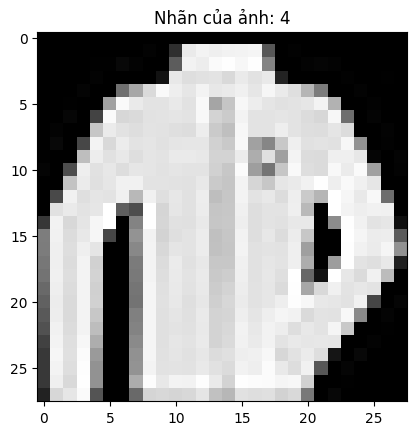

In [2]:
# Lấy thử 1 batch dữ liệu
images, labels = next(iter(train_loader))

print(f"Kích thước của 1 batch ảnh: {images.shape}") 
# Kết quả sẽ là [64, 1, 28, 28] -> 64 ảnh, 1 kênh màu (ảnh xám), cao 28, rộng 28

# Vẽ thử 1 bức ảnh đầu tiên
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Nhãn của ảnh: {labels[0].item()}")
plt.show()

In [3]:
class MLP_Fashion(nn.Module):
    def __init__(self):
        super(MLP_Fashion, self).__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28 * 28, 512)
        
        self.relu1 = nn.ReLU()

        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(512, 256)
        
        self.relu2 = nn.ReLU()

        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(256, 10)
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        logits = self.fc3(x)
        return logits

model = MLP_Fashion().to(device)
print(model)

MLP_Fashion(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


[Epoch 1, Batch 300] Loss: 1.9150
[Epoch 1, Batch 600] Loss: 0.9626
[Epoch 1, Batch 900] Loss: 0.7576
Epoch 1 - Test Accuracy: 77.54%
[Epoch 2, Batch 300] Loss: 0.6247
[Epoch 2, Batch 600] Loss: 0.5744
[Epoch 2, Batch 900] Loss: 0.5435
Epoch 2 - Test Accuracy: 82.29%
[Epoch 3, Batch 300] Loss: 0.4936
[Epoch 3, Batch 600] Loss: 0.4697
[Epoch 3, Batch 900] Loss: 0.4551
Epoch 3 - Test Accuracy: 84.15%
[Epoch 4, Batch 300] Loss: 0.4305
[Epoch 4, Batch 600] Loss: 0.4373
[Epoch 4, Batch 900] Loss: 0.4113
Epoch 4 - Test Accuracy: 85.14%
[Epoch 5, Batch 300] Loss: 0.4151
[Epoch 5, Batch 600] Loss: 0.4021
[Epoch 5, Batch 900] Loss: 0.4034
Epoch 5 - Test Accuracy: 85.19%
[Epoch 6, Batch 300] Loss: 0.4101
[Epoch 6, Batch 600] Loss: 0.4025
[Epoch 6, Batch 900] Loss: 0.3857
Epoch 6 - Test Accuracy: 84.85%
[Epoch 7, Batch 300] Loss: 0.3927
[Epoch 7, Batch 600] Loss: 0.3807
[Epoch 7, Batch 900] Loss: 0.3701
Epoch 7 - Test Accuracy: 86.21%
[Epoch 8, Batch 300] Loss: 0.3659
[Epoch 8, Batch 600] Loss: 0

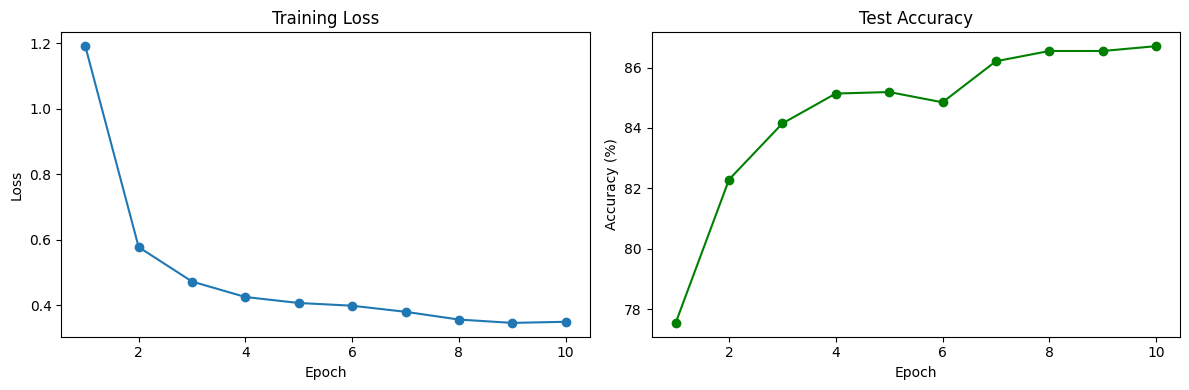

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001)

step_size_up = len(train_loader) * 2 

scheduler = torch.optim.lr_scheduler.CyclicLR(
    optimizer, 
    base_lr=0.001, # Tốc độ học nhỏ nhất (Min)
    max_lr=0.01,   # Tốc độ học lớn nhất (Max)
    step_size_up=step_size_up,
    mode='triangular' # Đồ thị hình tam giác như bạn thấy trên widget
)

epochs = 10
train_losses = []
test_accuracies = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    epoch_loss = 0.0
    for i, (x,y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        z = model(x)
        
        loss = criterion(z, y)

        loss.backward()

        optimizer.step()

        scheduler.step()

        epoch_loss += loss.item()

        running_loss += loss.item()

        if i % 300 == 299:    
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 300:.4f}')
            running_loss = 0.0
    train_losses.append(epoch_loss / len(train_loader))
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    acc = 100 * correct / total
    test_accuracies.append(acc)
    print(f'Epoch {epoch + 1} - Test Accuracy: {100 * correct / total:.2f}%')

print("Huấn luyện hoàn tất!")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, epochs + 1), train_losses, marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(1, epochs + 1), test_accuracies, marker='o', color='green')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()



In [5]:
torch.save(model.state_dict(), 'fashion_mlp.pth')